# Twitter Sentiment Analysis — MLOps Pipeline
**MAI201 Machine Learning Operations · Seneca Polytechnic**

Team: Debolina Das (ML Lead) · Monireh Eshghinezhad (Engineering Lead) · Anish Dasgupta (Project Lead)

This notebook walks through the full milestone end-to-end:
1. **Dataset** — load and explore Sentiment140 (source, size, features, quality)
2. **Prepare** — clean tweets and create a stratified train/test split
3. **Train** — TF-IDF + Logistic Regression **baseline**, tracked with MLflow
4. **Experiments** — 2 additional MLflow-tracked runs (bigrams, Naive Bayes)
5. **Evaluate** — test metrics + confusion matrix
6. **Compare** — view all runs in the MLflow UI (screenshots for the deliverable)

> **Before running:** download Sentiment140 from Kaggle
> (https://www.kaggle.com/datasets/kazanova/sentiment140) and place the CSV at
> `data/raw/sentiment140.csv` relative to this notebook.

## 0. Setup
Install dependencies (skip if you already ran `pip install -r requirements.txt`).

In [2]:
# %pip install pandas scikit-learn mlflow matplotlib seaborn pyyaml

import os, re, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

RANDOM_STATE = 42
pd.set_option("display.max_colwidth", 120)
print("Setup complete")

/opt/anaconda3/envs/mlops-validation/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete


## 1. Dataset — Sentiment140

| Attribute | Details |
|---|---|
| **Source** | Kaggle — kazanova/sentiment140 |
| **Size** | 1,600,000 tweets (~238 MB, latin-1, **no header row**) |
| **Features** | `target`, `id`, `date`, `flag`, `user`, `text` |
| **Labels** | `0` = negative, `4` = positive (the released set has **no neutral** tweets → binary task) |
| **Labeling** | Distant supervision via emoticons (noisy labels ⇒ accuracy ceiling < 100%) |
| **Period / language** | 2009–2010, English |

In [3]:
import os
os.chdir("/Users/aastha/Desktop/MS - AI/Semester - 2/MAI - ML Operations/Project - Phase 1/twitter-sentiment-mlops")
print(os.getcwd())

/Users/aastha/Desktop/MS - AI/Semester - 2/MAI - ML Operations/Project - Phase 1/twitter-sentiment-mlops


In [4]:
RAW_PATH = "data/raw/sentiment140.csv"
RAW_COLUMNS = ["target", "id", "date", "flag", "user", "text"]

assert os.path.exists(RAW_PATH), (
    f"Dataset not found at {RAW_PATH}. Download it from "
    "https://www.kaggle.com/datasets/kazanova/sentiment140 and place the CSV there.")

df = pd.read_csv(RAW_PATH, encoding="latin-1", header=None, names=RAW_COLUMNS)
print(f"Rows: {len(df):,}  Columns: {list(df.columns)}")
df.head(25)

Rows: 1,600,000  Columns: ['target', 'id', 'date', 'flag', 'user', 'text']


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."
5,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
6,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,mybirch,Need a hug
7,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,coZZ,"@LOLTrish hey long time no see! Yes.. Rains a bit ,only a bit LOL , I'm fine thanks , how's you ?"
8,0,1467811795,Mon Apr 06 22:20:05 PDT 2009,NO_QUERY,2Hood4Hollywood,@Tatiana_K nope they didn't have it
9,0,1467812025,Mon Apr 06 22:20:09 PDT 2009,NO_QUERY,mimismo,@twittera que me muera ?


### 1.1 Exploratory Data Analysis

target
0    800000
4    800000
Name: count, dtype: int64


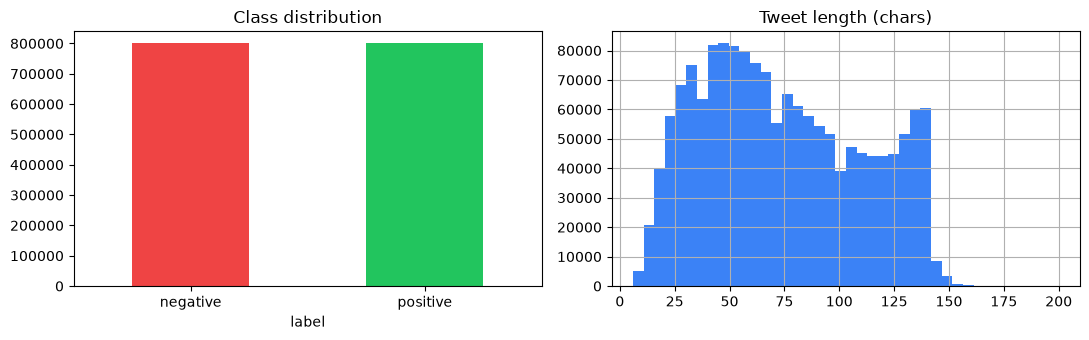

Nulls per column:
 target    0
id        0
date      0
flag      0
user      0
text      0
label     0
dtype: int64
Duplicate texts: 18534
Tweets containing URLs:      0.044
Tweets containing @mentions: 0.462


In [5]:
# Class distribution — balanced by construction (800K / 800K)
print(df["target"].value_counts())

# Binary label: 1 = positive, 0 = negative
df = df[df["target"].isin([0, 4])].copy()
df["label"] = (df["target"] == 4).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
df["label"].value_counts().plot(kind="bar", ax=axes[0], color=["#ef4444", "#22c55e"])
axes[0].set_title("Class distribution"); axes[0].set_xticklabels(["negative", "positive"], rotation=0)

df["text"].str.len().clip(upper=200).hist(bins=40, ax=axes[1], color="#3b82f6")
axes[1].set_title("Tweet length (chars)")
plt.tight_layout(); plt.show()

# Data-quality check: nulls, duplicates, noise patterns
print("Nulls per column:\n", df.isna().sum())
print("Duplicate texts:", df['text'].duplicated().sum())
print("Tweets containing URLs:     ", df['text'].str.contains(r'http', regex=True).mean().round(3))
print("Tweets containing @mentions:", df['text'].str.contains(r'@\w+', regex=True).mean().round(3))

**EDA takeaways** (documented for the report):
- Perfectly balanced classes → accuracy is a meaningful metric, no resampling needed.
- A large share of tweets contain URLs and @mentions → carry no sentiment signal, must be removed.
- `id`, `date`, `flag`, `user` columns carry no sentiment signal → dropped.
- Labels come from emoticons (distant supervision), so a few percent label noise is expected.

## 2. Prepare — cleaning + stratified split
Mirrors `src/prepare.py` (stage 1 of the DVC pipeline).

`SAMPLE_SIZE = 100_000` keeps training fast on a laptop; set it to `None` for the full 1.6M final run.

In [6]:
SAMPLE_SIZE = 100_000   # None = full dataset
TEST_SIZE = 0.2

URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
WS_RE = re.compile(r"\s+")

def clean_text(t: str) -> str:
    t = t.lower()
    t = URL_RE.sub(" ", t)
    t = MENTION_RE.sub(" ", t)
    t = t.replace("#", " ")
    return WS_RE.sub(" ", t).strip()

work = df
if SAMPLE_SIZE:
    n = min(SAMPLE_SIZE // 2, df["label"].value_counts().min())
    work = (df.groupby("label")
              .sample(n=n, random_state=RANDOM_STATE)
              .reset_index(drop=True))

work = work.copy()
work["text"] = work["text"].astype(str).map(clean_text)
work = work[work["text"].str.len() > 0][["text", "label"]]

train_df, test_df = train_test_split(work, test_size=TEST_SIZE,
                                     random_state=RANDOM_STATE, stratify=work["label"])
print(f"Train: {len(train_df):,}   Test: {len(test_df):,}")
train_df.head(3)

/var/folders/0f/h7hw1pd12cz1bw9zm1fgjb000000gn/T/ipykernel_46837/1056357639.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), SAMPLE_SIZE // 2), random_state=RANDOM_STATE))


Train: 79,857   Test: 19,965


,text,label
65609,sad that the dallas mavericks season is over...now time to focus on the 1st place texas rangers and the pga tour com...,1
47575,just shopped for britain!! i am officially broke now,0
7490,i need to go to la for demis video shoot tomorrow!!! ....,0


## 3. MLflow setup + a reusable train/evaluate function
Every run logs **params, train/test metrics, and the model artifact** to a local SQLite backend (`mlflow.db`).

In [7]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("twitter-sentiment-analysis")

X_train, y_train = train_df["text"], train_df["label"]
X_test,  y_test  = test_df["text"],  test_df["label"]

def run_experiment(run_name, vectorizer, model, extra_params=None):
    """Fit pipeline, evaluate on test set, log everything to one MLflow run."""
    pipe = Pipeline([("vectorizer", vectorizer), ("clf", model)])
    with mlflow.start_run(run_name=run_name):
        params = {"vectorizer": type(vectorizer).__name__,
                  "model": type(model).__name__,
                  "train_rows": len(X_train), **(extra_params or {})}
        mlflow.log_params(params)

        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)

        metrics = {"test_accuracy":  accuracy_score(y_test, preds),
                   "test_precision": precision_score(y_test, preds),
                   "test_recall":    recall_score(y_test, preds),
                   "test_f1":        f1_score(y_test, preds)}
        if hasattr(pipe.named_steps["clf"], "predict_proba"):
            metrics["test_auc_roc"] = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])

        mlflow.log_metric("train_accuracy", pipe.score(X_train, y_train))
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(pipe, name="model")

        print(f"[{run_name}] " + "  ".join(f"{k}={v:.4f}" for k, v in metrics.items()))
        return pipe, metrics

print("MLflow ready — tracking to sqlite:///mlflow.db")

MLflow ready — tracking to sqlite:///mlflow.db


## 4. Baseline — TF-IDF (unigrams) + Logistic Regression

In [ ]:
baseline_model, baseline_metrics = run_experiment(
    "baseline-logreg-tfidf-ng1",
    TfidfVectorizer(max_features=50_000, ngram_range=(1, 1)),
    LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced"),
    extra_params={"max_features": 50_000, "ngram_max": 1, "C": 1.0})

for k, v in baseline_metrics.items():
    print(f"{k}: {v:.4f}")

## 5. Experiment 1 — add bigrams (`ngram_range=(1,2)`)
Hypothesis: bigrams capture negations like *"not good"* that unigrams miss.

In [15]:
exp1_model, exp1_metrics = run_experiment(
    "exp1-logreg-tfidf-ng2",
    TfidfVectorizer(max_features=50_000, ngram_range=(1, 2)),
    LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced"),
    extra_params={"max_features": 50_000, "ngram_max": 2, "C": 1.0})


for k, v in exp1_metrics.items():
    print(f"{k}: {v:.4f}")

[exp1-logreg-tfidf-ng2] test_accuracy=0.7910  test_precision=0.7876  test_recall=0.7970  test_f1=0.7923  test_auc_roc=0.8714
test_accuracy: 0.7910
test_precision: 0.7876
test_recall: 0.7970
test_f1: 0.7923
test_auc_roc: 0.8714


## 6. Experiment 2 — Multinomial Naive Bayes + count features
Hypothesis: a classic fast text baseline — how close does it get to logistic regression?

In [10]:
exp2_model, exp2_metrics = run_experiment(
    "exp2-naivebayes-count-ng2",
    CountVectorizer(max_features=50_000, ngram_range=(1, 2)),
    MultinomialNB(),
    extra_params={"max_features": 50_000, "ngram_max": 2})

[exp2-naivebayes-count-ng2] test_accuracy=0.7762  test_precision=0.7844  test_recall=0.7618  test_f1=0.7730  test_auc_roc=0.8445


## 7. Evaluate — compare runs + confusion matrix of the best model

In [11]:
results = pd.DataFrame({
    "baseline (logreg, ng1)": baseline_metrics,
    "exp1 (logreg, ng2)":     exp1_metrics,
    "exp2 (NB, count ng2)":   exp2_metrics,
}).T.round(4)
results

,test_accuracy,test_precision,test_recall,test_f1,test_auc_roc
"baseline (logreg, ng1)",0.7824,0.7781,0.7904,0.7842,0.8626
"exp1 (logreg, ng2)",0.7910,0.7876,0.7970,0.7923,0.8714
"exp2 (NB, count ng2)",0.7762,0.7844,0.7618,0.7730,0.8445


Best model by test F1: exp1 (logreg, ng2)
              precision    recall  f1-score   support

    negative       0.79      0.78      0.79      9981
    positive       0.79      0.80      0.79      9984

    accuracy                           0.79     19965
   macro avg       0.79      0.79      0.79     19965
weighted avg       0.79      0.79      0.79     19965



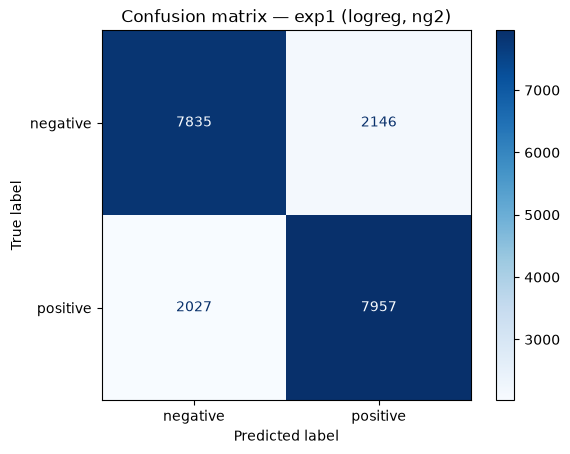

In [12]:
best_name = results["test_f1"].idxmax()
best_model = {"baseline (logreg, ng1)": baseline_model,
              "exp1 (logreg, ng2)": exp1_model,
              "exp2 (NB, count ng2)": exp2_model}[best_name]
print("Best model by test F1:", best_name)

preds = best_model.predict(X_test)
print(classification_report(y_test, preds, target_names=["negative", "positive"]))

ConfusionMatrixDisplay(confusion_matrix(y_test, preds),
                       display_labels=["negative", "positive"]).plot(cmap="Blues")
plt.title(f"Confusion matrix — {best_name}")
plt.show()

In [13]:
# Sanity check on hand-written examples
samples = ["I absolutely love this, best day ever!",
           "this is terrible, worst service I've had",
           "not bad at all, actually pretty great",
           "I am so disappointed and sad right now"]
for s, p in zip(samples, best_model.predict(samples)):
    print(f"{'POSITIVE' if p==1 else 'NEGATIVE'}  <-  {s}")

POSITIVE  <-  I absolutely love this, best day ever!
NEGATIVE  <-  this is terrible, worst service I've had
POSITIVE  <-  not bad at all, actually pretty great
NEGATIVE  <-  I am so disappointed and sad right now


## 8. View runs in the MLflow UI (screenshots for the deliverable)

In a terminal, from this notebook's folder (with your venv active):

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

Open http://127.0.0.1:5000 → experiment **twitter-sentiment-analysis**.

**Screenshots to capture:**
1. Experiment page listing all 3 runs (baseline + 2 experiments)
2. Select all runs → **Compare** → params vs. `test_accuracy` / `test_f1` table
3. One run's detail page showing params, metrics, and the logged model artifact

## 9. Conclusions (fill in for your report)
- Which configuration won, and by how much?
- Did bigrams help (negation handling)? Was NB competitive at lower cost?
- Metrics vs. proposal targets (accuracy ≥ 80%, F1 ≥ 0.73/class, AUC ≥ 0.80) — met on the 100K sample? On the full 1.6M run?